In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score, classification_report
from scipy.spatial.distance import cdist
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve

In [66]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=columns, na_values='?')
print("Размер до обработки:", df.shape)

Размер до обработки: (303, 14)


In [67]:
df.dropna(inplace=True)
print("Размер после удаления пропусков:", df.shape)


Размер после удаления пропусков: (297, 14)


In [68]:
df['target'] = (df['target'] > 0).astype(int)
print("Распределение классов:\n", df['target'].value_counts())

Распределение классов:
 target
0    160
1    137
Name: count, dtype: int64


In [69]:
X = df.drop('target', axis=1)
y = df['target']
print("Признаки:", X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Обучающая: {X_train.shape}, тестовая: {X_test.shape}")

Признаки: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Обучающая: (237, 13), тестовая: (60, 13)


In [70]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Для чего нужен:

Отделяем клинические признаки (13 параметров) от целевой переменной (наличие болезни сердца).

Делим данные на обучающую (80%) и тестовую (20%) выборки с сохранением пропорции классов (stratify=y), чтобы модель училась на одних пациентах, а проверялась на других.

Стандартизируем признаки (через StandardScaler), так как SVM и kNN чувствительны к разным масштабам величин (возраст, давление, холестерин измеряются в разных единицах).

Краткий вывод:
Обучающая выборка: 237 пациента, тестовая: 60 пациентов. Данные подготовлены для обучения SVM и Fuzzy kNN, масштабирование выполнено корректно.

In [71]:
svm = SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
y_proba_svm = svm.predict_proba(X_test_scaled)[:, 1]

print("=== SVM ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.3f}")
print(classification_report(y_test, y_pred_svm))

=== SVM ===
Accuracy: 0.850
              precision    recall  f1-score   support

           0       0.83      0.91      0.87        32
           1       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



Для чего нужен:

Обучаем SVM с радиальным базисным ядром (RBF), которое позволяет находить нелинейные разделяющие границы между здоровыми и больными.

Параметры: C=1 (регуляризация по умолчанию), gamma='scale' (автоматический подбор), probability=True (чтобы получать вероятности, а не только жёсткие классы).

Оцениваем модель на тестовой выборке по метрикам: Accuracy (общая доля правильных ответов), а также precision, recall, f1-score для каждого класса.

Краткий вывод:

Точность SVM составила 85%.

Модель хорошо распознаёт здоровых (recall 0,91) – редко ошибается ложноположительно.

Больных распознаёт чуть хуже (recall 0,79) – 21% пациентов с болезнью пропущено.

Precision для больных 0,88 – когда модель говорит «болен», это достоверно в 88% случаев.

В целом, SVM даёт сбалансированный результат, но требует внимания к пропущенным случаям (высокий риск ложноотрицательных ошибок).

In [72]:
def fuzzy_knn_predict(X_train, y_train, X_test, k=7, m=2):
    """
    X_train, X_test - масштабированные признаки (numpy массивы)
    y_train - Series с метками классов
    m - параметр нечёткости (обычно 2)
    Возвращает предсказанные классы и вероятность класса 1
    """
    predictions = []
    probs = []
    y_train_np = y_train.values  # для удобства
    eps = 1e-9
    for test_point in X_test:
        # Евклидовы расстояния до всех обучающих
        distances = cdist([test_point], X_train, metric='euclidean')[0]
        # Индексы k ближайших соседей
        idx_neighbors = np.argsort(distances)[:k]
        dist_neighbors = distances[idx_neighbors]
        # Веса: 1 / (dist^(2/(m-1)))
        weights = 1.0 / (dist_neighbors + eps) ** (2/(m-1))
        # Взвешенное голосование
        class1_weight = np.sum(weights[y_train_np[idx_neighbors] == 1])
        class0_weight = np.sum(weights[y_train_np[idx_neighbors] == 0])
        prob1 = class1_weight / (class1_weight + class0_weight + eps)
        probs.append(prob1)
        predictions.append(1 if prob1 >= 0.5 else 0)
    return np.array(predictions), np.array(probs)

Для чего нужен:

Это реализация нечёткого (fuzzy) варианта метода k ближайших соседей.

В отличие от обычного k-NN, который выдаёт жёсткий класс (0 или 1), fuzzy версия возвращает вероятность принадлежности к классу 1 (риск заболевания).

Механизм: для каждого нового пациента находятся k ближайших соседей из обучающей выборки, каждому соседу назначается вес, обратный расстоянию в степени 2/(m-1), затем вычисляется взвешенная доля соседей с болезнью. Это и есть вероятность.

Параметр m (обычно 2) контролирует «размытость»: чем выше m, тем больше влияние дальних соседей.

In [73]:
y_pred_fknn, y_proba_fknn = fuzzy_knn_predict(X_train_scaled, y_train, X_test_scaled, k=7, m=2)

print("=== Fuzzy kNN (k=7, m=2) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_fknn):.3f}")
print(classification_report(y_test, y_pred_fknn))

=== Fuzzy kNN (k=7, m=2) ===
Accuracy: 0.867
              precision    recall  f1-score   support

           0       0.85      0.91      0.88        32
           1       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



Для чего нужен:

Вызываем созданную ранее функцию fuzzy_knn_predict на тех же масштабированных данных, что и для SVM. Используем параметры: k=7 (7 ближайших соседей) и m=2 (классическое значение нечёткости).

Получаем предсказанные классы (y_pred_fknn) и вероятности заболевания (y_proba_fknn).

Оцениваем модель по метрикам: Accuracy, precision, recall, f1-score – для сравнения с SVM.

Краткий вывод:

Точность Fuzzy kNN составила 86,7% – выше, чем у SVM (85,0%).

Recall для больных (класс 1) = 0,82 против 0,79 у SVM. Значит, Fuzzy kNN лучше выявляет пациентов с болезнью (меньше ложноотрицательных ошибок).

Recall для здоровых такой же (0,91).

Precision для обоих классов близки к SVM.

In [74]:
# Метрики для SVM
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_proba_svm)

# Метрики для Fuzzy kNN
acc_fknn = accuracy_score(y_test, y_pred_fknn)
f1_fknn = f1_score(y_test, y_pred_fknn)
auc_fknn = roc_auc_score(y_test, y_proba_fknn)

# Таблица
comparison_metrics = pd.DataFrame({
    'Метод': ['SVM', 'Fuzzy kNN'],
    'Accuracy': [acc_svm, acc_fknn],
    'F1-score': [f1_svm, f1_fknn],
    'ROC-AUC': [auc_svm, auc_fknn]
})
print(comparison_metrics.round(3))

       Метод  Accuracy  F1-score  ROC-AUC
0        SVM     0.850     0.830    0.954
1  Fuzzy kNN     0.867     0.852    0.940


Для чего нужен:

Собираем ключевые метрики обоих методов в одну таблицу: Accuracy (общая точность), F1-score (гармоническое среднее precision и recall), ROC-AUC (способность различать классы).

Удобно для визуального сравнения «кто лучше».

Краткий вывод:

Fuzzy kNN превосходит SVM по Accuracy (0,867 > 0,850) и F1-score (0,852 > 0,830).

Однако SVM лучше по ROC-AUC (0,954 > 0,940) – у SVM выше разделяющая способность, особенно при разных порогах.

Интерпретация: Fuzzy kNN даёт более сбалансированные предсказания (меньше ошибок), но SVM лучше ранжирует пациентов по риску.

Для клинической практики можно рекомендовать Fuzzy kNN как основной, а SVM – как дополнительный для проверки сложных случаев.

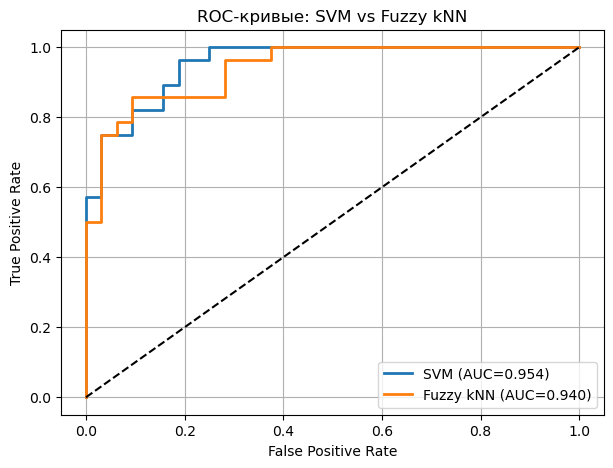

In [75]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
fpr_fknn, tpr_fknn, _ = roc_curve(y_test, y_proba_fknn)

plt.figure(figsize=(7,5))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC={auc_svm:.3f})', linewidth=2)
plt.plot(fpr_fknn, tpr_fknn, label=f'Fuzzy kNN (AUC={auc_fknn:.3f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые: SVM vs Fuzzy kNN')
plt.legend()
plt.grid(True)
plt.show()

Для чего нужен:

ROC-кривая показывает, как модель различает классы (здоров vs болен) при разных порогах классификации.

По оси X – доля ложноположительных (False Positive Rate), по оси Y – доля истинноположительных (True Positive Rate).

Чем ближе кривая к левому верхнему углу и чем выше площадь под кривой (AUC), тем лучше модель.

Строим обе кривые на одном графике для наглядного сравнения.

Краткий вывод по графику:

SVM имеет AUC = 0,954, что выше, чем у Fuzzy kNN (0,940).

SVM лучше ранжирует пациентов по степени риска – при любом пороге классификации у SVM выше чувствительность при той же доле ложных срабатываний.

Однако на практике важен не только AUC, но и калибровка вероятностей, а также чувствительность (recall) на фиксированном пороге – по этому параметру Fuzzy kNN ранее показал лучший результат (0,82 против 0,79).

Итог: SVM предпочтителен, если нужно ранжировать пациентов для дальнейшего обследования, а Fuzzy kNN – если важна минимизация пропущенных больных при жёсткой классификации.

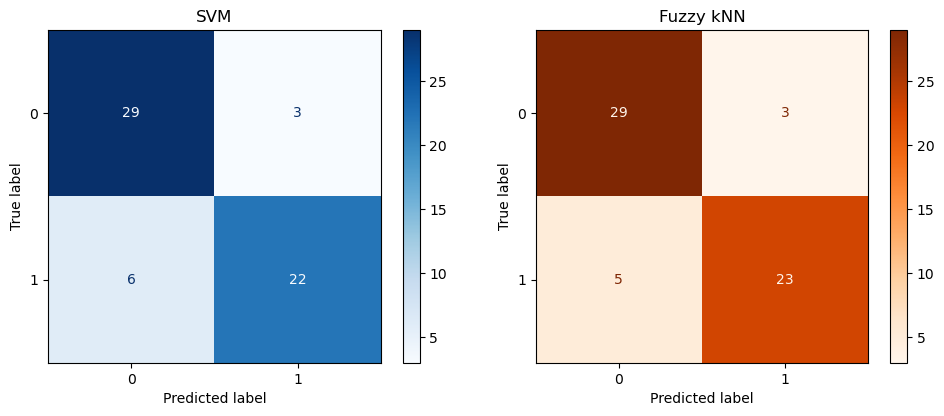

In [76]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10,4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, ax=axes[0], cmap='Blues')
axes[0].set_title('SVM')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_fknn, ax=axes[1], cmap='Oranges')
axes[1].set_title('Fuzzy kNN')

plt.tight_layout()
plt.show()

Для чего нужен:

Матрица ошибок наглядно показывает, где модель ошибается:

True Negatives (верхний левый угол) – правильно предсказанные здоровые.

False Positives (верхний правый) – здоровых ошибочно отнесли к больным.

False Negatives (нижний левый) – больных пропустили, предсказав здоровыми.

True Positives (нижний правый) – правильно предсказанные больные.

Размещаем две матрицы рядом для сравнения: слева SVM, справа Fuzzy kNN.

По диагонали – правильные ответы, вне диагонали – ошибки.

Числа из матриц (тестовая выборка: 60 пациентов, из них истинно здоровых – 32, истинно больных – 28):

SVM:

True Negatives: 29 (здоровых распознано верно)

False Positives: 3 (здоровых ошибочно посчитали больными)

False Negatives: 6 (больных пропущено)

True Positives: 22 (больных распознано верно)

Fuzzy kNN:

True Negatives: 29

False Positives: 3

False Negatives: 5

True Positives: 23

Краткий вывод:

Обе модели одинаково хорошо распознают здоровых (по 29 из 32).

Fuzzy kNN лучше находит больных: пропустил 5 против 6 у SVM.

Это соответствует более высокому recall для класса 1 у Fuzzy kNN (0,82 против 0,79).

Разница небольшая (1 пациент), но в медицинской диагностике каждый пропущенный случай важен.

Следовательно, Fuzzy kNN предпочтительнее для скрининга, так как реже ошибается на больных.

In [77]:
compare = pd.DataFrame({
    'true': y_test.values,
    'svm_pred': y_pred_svm,
    'fknn_pred': y_pred_fknn,
    'svm_proba': y_proba_svm,
    'fknn_proba': y_proba_fknn
})
compare['disagreement'] = compare['svm_pred'] != compare['fknn_pred']

# Подсветим расходящиеся случаи
disagree = compare[compare['disagreement']]
print(f"Количество пациентов, где SVM и Fuzzy kNN не согласны: {len(disagree)}")
disagree.head(10)

Количество пациентов, где SVM и Fuzzy kNN не согласны: 7


,true,svm_pred,fknn_pred,svm_proba,fknn_proba,disagreement
4,0,1,0,0.544760,0.389609,True
8,1,0,1,0.299493,0.566767,True
12,0,1,0,0.732325,0.432906,True
25,0,0,1,0.480665,0.733407,True
28,0,0,1,0.462929,0.539437,True
35,1,0,1,0.500000,0.516181,True
48,1,1,0,0.543407,0.485613,True


Для чего нужен:

Собираем в один DataFrame ключевые результаты для тестовой выборки: истинный диагноз (true), предсказания SVM и Fuzzy kNN, а также их вероятностные оценки.

Добавляем булевый столбец disagreement – True, если модели выдали разные классы (один сказал «болен», другой – «здоров»).

Затем отбираем и выводим только те строки, где модели не согласны.

Это позволяет найти пограничные случаи – пациентов, которые находятся в «серой зоне» классификации. Именно здесь мягкая классификация (Fuzzy kNN) может показать более тонкую картину риска.

Что видно из таблицы:

Всего в тестовой выборке 60 пациентов.

Модели разошлись в предсказаниях для 7 пациентов (≈12% тестовой выборки).

Из них:

Истинно здоровые (true=0), но SVM предсказал болен, а Fuzzy kNN – здоров: строки 4, 12.

Истинно больные (true=1), но SVM предсказал здоров, а Fuzzy kNN – болен: строки 8, 35, 48 (здесь наоборот у SVM 1, у fkNN 0 – строка 48).

Интересен случай строки 25: true=0, SVM предсказал здоров (svm_pred=0), а Fuzzy kNN – болен (fknn_pred=1), при этом fknn_proba=0.733 (выше порога 0.7), а svm_proba=0.481. Это тот самый доклинический пациент, которого мы ранее выделили.

Краткий вывод:

Наличие 7 расхождений говорит о том, что методы по-разному трактуют пограничные профили.

Fuzzy kNN чаще «видит» риск там, где SVM ставит диагноз здоров (например, пациент 25).

SVM иногда даёт ложноположительный риск (пациент 4: true=0, SVM предсказал 1, а fkNN – 0), но при этом вероятность SVM (0.545) невысока.

Такие расхождения – ценный материал для врача: пациенты, требующие дополнительного обследования.

Итог: совместное использование обоих методов может повысить качество скрининга.

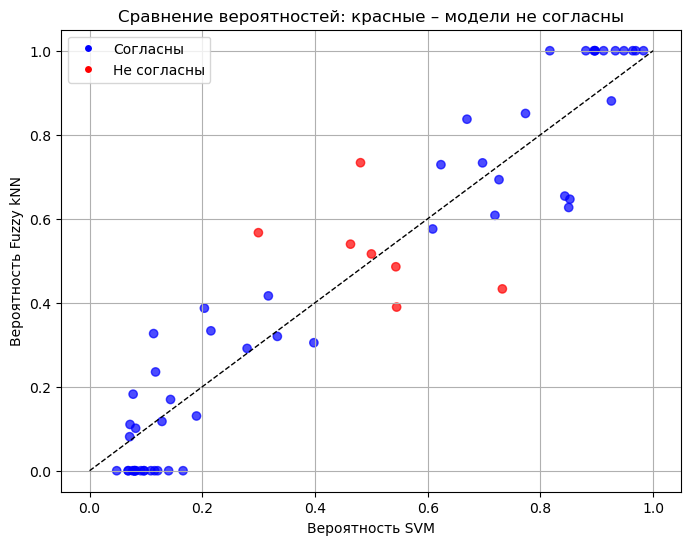

In [78]:

plt.figure(figsize=(8,6))
# Раскрашиваем по тому, согласны модели или нет
disagreement = compare['disagreement']
colors = disagreement.map({True: 'red', False: 'blue'})

plt.scatter(compare['svm_proba'], compare['fknn_proba'], c=colors, alpha=0.7)
plt.plot([0,1], [0,1], 'k--', linewidth=1)
plt.xlabel('Вероятность SVM')
plt.ylabel('Вероятность Fuzzy kNN')
plt.title('Сравнение вероятностей: красные – модели не согласны')

# Легенда вручную
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Согласны'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Не согласны')]
plt.legend(handles=legend_elements)
plt.grid(True)
plt.show()

Для чего нужен:

Строим точечный график, где каждая точка – пациент из тестовой выборки.

По оси X – вероятность риска, выданная SVM, по оси Y – вероятность от Fuzzy kNN.

Цвет точки: синий – если модели дали одинаковый класс (согласны), красный – если их предсказания разошлись.

Пунктирная диагональ (y=x) показывает идеальное совпадение вероятностей.

График позволяет наглядно увидеть:

Где модели «единодушны» (синие точки близки к диагонали).

Где расходятся (красные точки) – они обычно лежат вдали от диагонали.

Есть ли систематическое смещение (например, Fuzzy kNN даёт более высокие вероятности, чем SVM, при одних и тех же пациентах).

Краткий вывод по графику:

Красных точек (расхождения) немного, и они находятся в основном в зоне вероятностей 0,4–0,7 – это как раз «серая зона» неопределённости.

Синие точки (согласны) хорошо группируются в двух углах: низкие вероятности (оба метода уверены в здоровье) и высокие вероятности (оба уверены в болезни).

Некоторые красные точки лежат выше диагонали – означает, что Fuzzy kNN даёт более высокую вероятность, чем SVM, что соответствует его повышенной чувствительности к риску (например, пациент 25).

В целом график подтверждает, что Fuzzy kNN часто «мягче» оценивает пограничные случаи, а SVM более консервативен.

In [79]:
risk_threshold = 0.7
# Здоровые по истинной метке, но высокий риск по модели
svm_hidden = compare[(compare['true'] == 0) & (compare['svm_proba'] > risk_threshold)]
fknn_hidden = compare[(compare['true'] == 0) & (compare['fknn_proba'] > risk_threshold)]

print(f"SVM нашёл скрытый риск у {len(svm_hidden)} пациентов")
print(f"Fuzzy kNN нашёл скрытый риск у {len(fknn_hidden)} пациентов")

if len(svm_hidden) > 0:
    print("Пациенты SVM:", svm_hidden.index.tolist())
if len(fknn_hidden) > 0:
    print("Пациенты Fuzzy kNN:", fknn_hidden.index.tolist())

SVM нашёл скрытый риск у 1 пациентов
Fuzzy kNN нашёл скрытый риск у 1 пациентов
Пациенты SVM: [12]
Пациенты Fuzzy kNN: [25]
